In [16]:
#Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [17]:
# Loading and cleaning the raw data just like I did in task 1
df = pd.read_csv('../data/DA task.csv')

In [18]:
date_cols = ["TIMESTAMP", "CONVERTED_AT", "TRIAL_START", "TRIAL_END"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   ORGANIZATION_ID  170526 non-null  object        
 1   ACTIVITY_NAME    170526 non-null  object        
 2   TIMESTAMP        170526 non-null  datetime64[ns]
 3   CONVERTED        170526 non-null  bool          
 4   CONVERTED_AT     34235 non-null   datetime64[ns]
 5   TRIAL_START      170526 non-null  datetime64[ns]
 6   TRIAL_END        170526 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](4), object(2)
memory usage: 8.0+ MB


In [20]:
#lowercase
df.columns = df.columns.str.lower()

In [21]:
# Check missing values
print(df.isna().sum())


organization_id         0
activity_name           0
timestamp               0
converted               0
converted_at       136291
trial_start             0
trial_end               0
dtype: int64


In [22]:
#check for duplicates
df.duplicated().sum()

np.int64(67631)

In [23]:
# Derive days_into_trial and within_trial flag

df['days_into_trial'] = (df['timestamp'] - df['trial_start']).dt.days
df['within_trial'] = (df['timestamp'] >= df['trial_start']) & (df['timestamp'] <= df['trial_end'])

#filter for in windows events only
df_clean = df[df['within_trial']].copy()

print(f"Clean events: {len(df_clean):,}")
print(f"Unique orgs: {df_clean['organization_id'].nunique()}")

Clean events: 170,526
Unique orgs: 966


In [24]:
# Build the org-level summary table
# One row per org, same as Task 1 org_df

activity_counts = (
    df_clean
    .groupby(["organization_id", "activity_name"])
    .size()
    .unstack(fill_value=0)
)

org_stats = (
    df_clean
    .groupby("organization_id")
    .agg(
        converted         = ("converted",       "first"),
        converted_at      = ("converted_at",    "first"),
        trial_start       = ("trial_start",     "first"),
        trial_end         = ("trial_end",       "first"),
        total_events      = ("activity_name",   "count"),
        unique_activities = ("activity_name",   "nunique"),
        days_active       = ("days_into_trial", "nunique"),
        first_event_day   = ("days_into_trial", "min"),
        last_event_day    = ("days_into_trial", "max"),
    )
)

org_df = org_stats.join(activity_counts)

In [25]:
# ── Add trial cohort month ──

# This tells us which month each org started their trial. Useful for spotting whether newer cohorts behave differently.

org_df['trial_month'] = org_df['trial_start'].dt.to_period('M').astype(str)

print(f"Org Table Shape: {org_df.shape}")
print(f"\nTrial Cohort: \n{org_df['trial_month'].value_counts().sort_index()}")

Org Table Shape: (966, 38)

Trial Cohort: 
trial_month
2024-01    305
2024-02    347
2024-03    314
Name: count, dtype: int64


In [26]:
# ─ Overall conversion rate

total_orgs = len(org_df)
converted_orgs = org_df['converted'].sum()
conversion_rate = converted_orgs / total_orgs *100

print(" --- Overall Conversion Rate ---")

print(f"Total Orgs: {total_orgs:,}")
print(f"Converted orgs: {converted_orgs:,}")
print(f"Conversion Rate: {conversion_rate:.2f}%")

 --- Overall Conversion Rate ---
Total Orgs: 966
Converted orgs: 206
Conversion Rate: 21.33%


In [27]:
cohort_conv = (org_df.groupby('trial_month')
               .agg(total_orgs=('converted', 'count'), converted_orgs=('converted', 'sum'))
               .assign(conversion_rate= lambda x: (x['converted_orgs'] / x['total_orgs']* 100).round(2))
               )

print("\n --- Conversion Rate by Cohort Month ---")
print(cohort_conv.to_string())


 --- Conversion Rate by Cohort Month ---
             total_orgs  converted_orgs  conversion_rate
trial_month                                             
2024-01             305              70            22.95
2024-02             347              79            22.77
2024-03             314              57            18.15


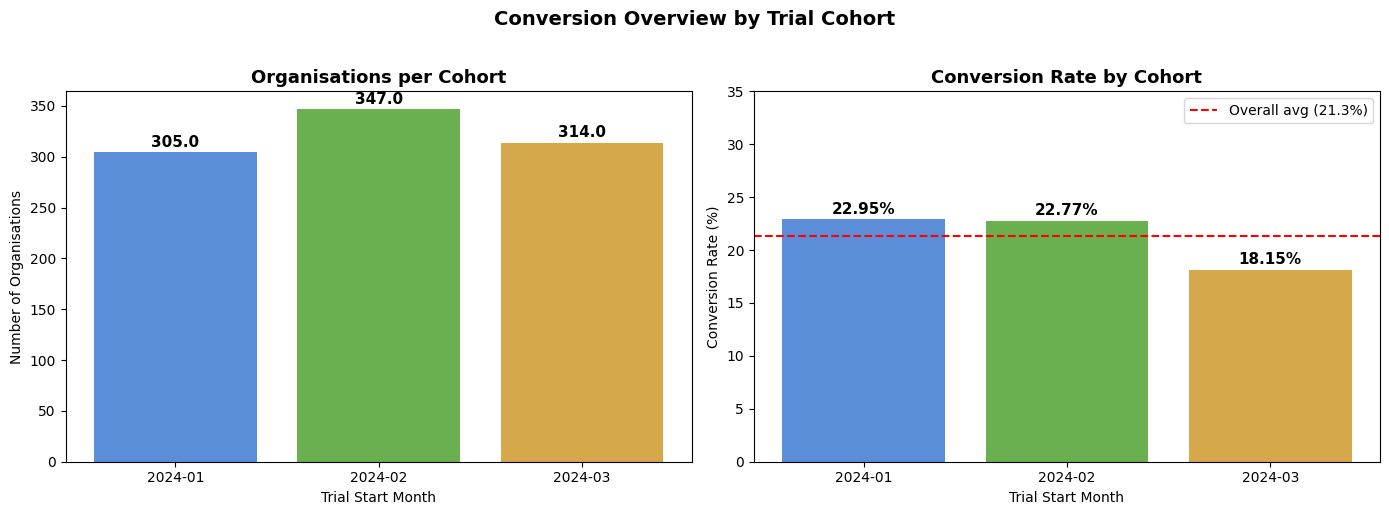

Chart saved.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: total orgs per cohort (size of each cohort)
axes[0].bar(
    cohort_conv.index,
    cohort_conv["total_orgs"],
    color=["#5b8dd9", "#6aaf50", "#d4a84b"],
    edgecolor="none"
)
axes[0].set_title("Organisations per Cohort", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Trial Start Month")
axes[0].set_ylabel("Number of Organisations")

for i, (idx, row) in enumerate(cohort_conv.iterrows()):
    axes[0].text(i, row["total_orgs"] + 5, str(row["total_orgs"]),
                 ha="center", fontsize=11, fontweight="bold")

# Right chart: conversion rate per cohort
bars = axes[1].bar(
    cohort_conv.index,
    cohort_conv["conversion_rate"],
    color=["#5b8dd9", "#6aaf50", "#d4a84b"],
    edgecolor="none"
)
axes[1].axhline(y=conversion_rate, color="red", linestyle="--",
                linewidth=1.5, label=f"Overall avg ({conversion_rate:.1f}%)")
axes[1].set_title("Conversion Rate by Cohort", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Trial Start Month")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].legend()
axes[1].set_ylim(0, 35)

for i, (idx, row) in enumerate(cohort_conv.iterrows()):
    axes[1].text(i, row["conversion_rate"] + 0.5,
                 f"{row['conversion_rate']}%",
                 ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Conversion Overview by Trial Cohort",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("conversion_by_cohort.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved.")

In [29]:
# ── Calculate days from trial start to conversion
# We only look at orgs that actually converted.
# days_to_convert = the date they converted minus the date their trial started, expressed in whole days.

converted_df = org_df[org_df['converted'] == 1].copy()
converted_df['days_to_convert'] = (converted_df['converted_at']- converted_df['trial_start']).dt.days

print("---- Days to Convert ----")
print(f"Converted orgs: {len(converted_df)}")
print(f"Median days to convert: {converted_df['days_to_convert'].median()}")
print(f"Mean:  {converted_df['days_to_convert'].mean()}")
print(f"Min: {converted_df['days_to_convert'].min()}")
print(f"Max: {converted_df['days_to_convert'].max()}")
print(f"\n Distribution")
print(converted_df['days_to_convert'].describe().round(1))

---- Days to Convert ----
Converted orgs: 206
Median days to convert: 30.0
Mean:  30.271844660194176
Min: 14
Max: 64

 Distribution
count    206.0
mean      30.3
std        8.2
min       14.0
25%       25.0
50%       30.0
75%       36.0
max       64.0
Name: days_to_convert, dtype: float64


In [ ]:
# ── Bucket conversions into time bands ──
# Instead of just looking at raw days, we group conversions into bands: within the first week, within two weeks, etc.
# This gives the product team a more actionable picture for example "50% of converters decide within 7 days"
# is a much more useful insight than a median number.

